# 🏠 Grupo 4 — Ames Housing | Fase 4
## Notebook 06: MLOps + RAG Tabular
**CRISP-DM:** Deployment

| Paso | Descripción |
|------|-------------|
| 1 | MLflow: tracking de todos los modelos (Fases 2 + 3) |
| 2 | MLflow Model Registry: Staging → Production |
| 3 | Versionado de datos: `metadata.json` |
| 4 | RAG Tabular: búsqueda de propiedades similares (embeddings 128D) |
| 5 | Precisión@K: evaluación de la recuperación |
| 6 | Dashboard de monitoreo por segmento |

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

project_root = os.getcwd()
while not os.path.exists(os.path.join(project_root, 'config', 'params.yaml')) and project_root != os.path.dirname(project_root):
    project_root = os.path.dirname(project_root)
os.chdir(project_root)
sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import json

from src.preprocessing import load_config
from src.utils import set_plot_style, save_fig, print_section
from src.mlops import setup_mlflow, log_all_models, register_best_model, save_data_metadata
from src.similarity import PropertySimilarity

set_plot_style()
cfg = load_config('config/params.yaml')

print('Imports OK')
print(f'Experimento MLflow : {cfg["mlflow"]["experiment_name"]}')
print(f'Modelo registrado  : {cfg["mlflow"]["registered_model_name"]}')

Imports OK
Experimento MLflow : ames_housing_grupo4
Modelo registrado  : ames_price_predictor


## 1. Cargar Datos y Modelos

In [2]:
X_train = np.load('data/processed/X_train.npy')
X_val   = np.load('data/processed/X_val.npy')
X_test  = np.load('data/processed/X_test.npy')
y_train = np.load('data/processed/y_train.npy')
y_val   = np.load('data/processed/y_val.npy')
y_test  = np.load('data/processed/y_test.npy')

raw_df = pd.read_csv('data/raw/ames_housing_raw.csv')

print(f'Test set: {X_test.shape[0]} propiedades x {X_test.shape[1]} features')
print(f'Raw dataset: {raw_df.shape}')

Test set: 440 propiedades x 263 features
Raw dataset: (2930, 81)


## 2. MLflow — Tracking de Experimentos

In [3]:
# Configurar MLflow
setup_mlflow(cfg)

# Métricas del MLP obtenidas del notebook 05 (sin importar torch aquí)
# Ajusta estos valores a los que salieron en tu corrida del notebook 05
mlp_metrics = {
    "R2":       0.8619,
    "RMSE_USD": 29401.0,
    "MAE_USD":  20388.0,
    "RMSE_log": 0.146266,
}
print('MLflow configurado OK')
print(f'Métricas MLP: R²={mlp_metrics["R2"]} | RMSE=${mlp_metrics["RMSE_USD"]:,.0f}')

[MLflow] Tracking URI : sqlite:///mlflow.db
[MLflow] Experimento  : ames_housing_grupo4
MLflow configurado OK
Métricas MLP: R²=0.8619 | RMSE=$29,401


In [4]:
# Registrar TODOS los modelos (Fase 2 + Fase 3) en MLflow
run_ids = log_all_models(
    X_test=X_test,
    y_test=y_test,
    cfg=cfg,
    mlp_metrics=mlp_metrics,
    best_epoch=113,   # cambia al número que salió en tu notebook 05
)

print(f'\nRuns registrados: {len(run_ids)}')
for name, rid in run_ids.items():
    print(f'  {name:10s}: {rid[:8]}...')

2026/06/15 17:42:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 17:42:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/15 17:42:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[MLflow] Ridge_Baseline       → run_id=106df152...  R²=0.9359  RMSE=$20,035


2026/06/15 17:42:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/15 17:42:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[MLflow] Random_Forest        → run_id=64e5696f...  R²=0.9017  RMSE=$24,805


2026/06/15 17:42:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/15 17:43:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 17:43:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[MLflow] XGBoost              → run_id=0ee2e18a...  R²=0.9219  RMSE=$22,106
[MLflow] AutoML_FLAML         → run_id=9ba34ad0...  R²=0.9311  RMSE=$20,773
[MLflow] MLP_Tabular          → run_id=fc13bc72...  R²=0.8619  RMSE=$29,401

Runs registrados: 5
  Ridge     : 106df152...
  RF        : 64e5696f...
  XGBoost   : 0ee2e18a...
  AutoML    : 9ba34ad0...
  MLP       : fc13bc72...


In [5]:
# Ver experimentos registrados
import mlflow

client = mlflow.tracking.MlflowClient()
exp    = client.get_experiment_by_name(cfg['mlflow']['experiment_name'])
runs   = client.search_runs(exp.experiment_id, order_by=['metrics.R2 DESC'])

rows = []
for r in runs:
    rows.append({
        'Modelo':     r.data.tags.get('model_type', r.info.run_name),
        'Fase':       r.data.tags.get('phase', '-'),
        'R²':         round(r.data.metrics.get('R2', 0), 4),
        'RMSE (USD)': f"${r.data.metrics.get('RMSE_USD', 0):,.0f}",
        'MAE (USD)':  f"${r.data.metrics.get('MAE_USD', 0):,.0f}",
    })

mlflow_df = pd.DataFrame(rows)
print('\n[MLflow] Experimentos registrados:')
print(mlflow_df.to_string(index=False))
print(f'\nMLflow UI: ejecutar → mlflow ui')
print(f'Luego abrir: http://localhost:5000')


[MLflow] Experimentos registrados:
        Modelo           Fase     R² RMSE (USD) MAE (USD)
Ridge_Baseline   2-ML_Clasico 0.9359    $20,035   $13,398
Ridge_Baseline   2-ML_Clasico 0.9359    $20,035   $13,398
Ridge_Baseline   2-ML_Clasico 0.9359    $20,035   $13,398
  AutoML_FLAML   2-ML_Clasico 0.9311    $20,773   $13,552
  AutoML_FLAML   2-ML_Clasico 0.9311    $20,773   $13,552
  AutoML_FLAML   2-ML_Clasico 0.9311    $20,773   $13,552
       XGBoost   2-ML_Clasico 0.9219    $22,106   $13,576
       XGBoost   2-ML_Clasico 0.9219    $22,106   $13,576
       XGBoost   2-ML_Clasico 0.9219    $22,106   $13,576
 Random_Forest   2-ML_Clasico 0.9017    $24,805   $14,972
 Random_Forest   2-ML_Clasico 0.9017    $24,805   $14,972
 Random_Forest   2-ML_Clasico 0.9017    $24,805   $14,972
   MLP_Tabular 3-DeepLearning 0.8619    $29,401   $20,388
   MLP_Tabular 3-DeepLearning 0.8619    $29,401   $20,388
   MLP_Tabular 3-DeepLearning 0.8619    $29,401   $20,388

MLflow UI: ejecutar → mlflow ui
Lue

## 3. MLflow Model Registry — Staging → Production

In [6]:
# Registrar el mejor modelo (Ridge, R²=0.9359) en Production
best_run_id = run_ids['Ridge']

print('[Registry] Promoviendo Ridge → Staging...')
register_best_model(best_run_id, cfg, stage='Staging')

print('[Registry] Promoviendo Ridge → Production...')
register_best_model(best_run_id, cfg, stage='Production')

# Listar modelos registrados
registered = client.search_registered_models(
    filter_string=f"name='{cfg['mlflow']['registered_model_name']}'"
)
for rm in registered:
    print(f'\nModelo registrado: {rm.name}')
    for mv in rm.latest_versions:
        print(f'  v{mv.version} → {mv.current_stage}')

[Registry] Promoviendo Ridge → Staging...


Registered model 'ames_price_predictor' already exists. Creating a new version of this model...
2026/06/15 17:43:08 WARNING mlflow.tracking._model_registry.fluent: Run with id 106df15210aa40a29d26558714fd0223 has no artifacts at artifact path 'model', registering model based on models:/m-af1141960bd84c5da73976927f0b966a instead


[MLflow Registry] Modelo 'ames_price_predictor' v5 → Staging
[Registry] Promoviendo Ridge → Production...


Created version '5' of model 'ames_price_predictor'.
Registered model 'ames_price_predictor' already exists. Creating a new version of this model...
2026/06/15 17:43:08 WARNING mlflow.tracking._model_registry.fluent: Run with id 106df15210aa40a29d26558714fd0223 has no artifacts at artifact path 'model', registering model based on models:/m-af1141960bd84c5da73976927f0b966a instead
Created version '6' of model 'ames_price_predictor'.

[MLflow Registry] Modelo 'ames_price_predictor' v6 → Production

Modelo registrado: ames_price_predictor
  v6 → Production
  v5 → Staging


## 4. Versionado de Datos — metadata.json

In [7]:
save_data_metadata(cfg, save_path='data/processed/metadata.json')

with open('data/processed/metadata.json') as f:
    meta = json.load(f)

print(json.dumps(meta, indent=2, ensure_ascii=False))

[Metadata] Guardado: data/processed/metadata.json
{
  "project": "Ames Housing â€” Grupo 4 SIS-351",
  "created_at": "2026-06-15T17:43:08.903560",
  "dataset": {
    "source": "OpenML ID 41211",
    "records": 2930,
    "features": 81,
    "target": "Sale_Price",
    "outliers_removed": 3
  },
  "splits": {
    "random_state": 42,
    "strategy": "stratified by price quintiles",
    "train": {
      "rows": 2048,
      "features": 263
    },
    "val": {
      "rows": 439,
      "features": 263
    },
    "test": {
      "rows": 440,
      "features": 263
    }
  },
  "file_hashes": {
    "X_train.npy": "a7dc7f403a8b",
    "X_val.npy": "38f637821919",
    "X_test.npy": "533b03c23ecb",
    "preprocessor.pkl": "f425b9b337b4"
  },
  "preprocessing": {
    "log_transform_target": true,
    "numeric_features": 263,
    "encoding": "OneHotEncoder (handle_unknown=ignore)"
  }
}


## 5. RAG Tabular — Búsqueda de Propiedades Similares

Dado una propiedad, los embeddings 128D del MLP permiten encontrar las propiedades más similares en el espacio latente. Esto funciona como **Retrieval** en un sistema RAG tabular.

In [8]:
# Cargar índice de similitud
sim = PropertySimilarity(metric=cfg['similarity']['metric'])
sim.fit(
    embeddings_path='models/mlp_embeddings.npy',
    labels_path='models/mlp_embeddings_labels.npy',
    raw_df=raw_df,
)
sim.summary()

[Similarity] 2927 propiedades indexadas | backend=FAISS (IndexFlatIP) | dim=128

[Similarity] Resumen del índice:
  Total propiedades : 2927
  Dimensión embedding: 128
  Métrica           : cosine
  Distribución por segmento:
    $120k-$200k         : 1533 (52.4%)
    $200k-$300k         :  627 (21.4%)
    <$120k              :  537 (18.3%)
    >$300k              :  230 (7.9%)


In [9]:
# Búsqueda de ejemplo: propiedad 100
K = cfg['similarity']['k_neighbors']
QUERY_IDX = 100

query_price = float(sim.prices_usd[QUERY_IDX])
query_seg   = sim.segments[QUERY_IDX]

print(f'Propiedad query  #{QUERY_IDX}')
print(f'  Precio real    : ${query_price:,.0f}')
print(f'  Segmento       : {query_seg}')
print(f'\nTop-{K} propiedades más similares:')

neighbors = sim.search(query_idx=QUERY_IDX, k=K)
print(neighbors.to_string(index=False))

Propiedad query  #100
  Precio real    : $280,000
  Segmento       : $200k-$300k

Top-5 propiedades más similares:
 idx  similarity  price_usd     segment  Gr_Liv_Area  Overall_Qual  Year_Built        Neighborhood  Total_Bsmt_SF  Garage_Cars
2665      0.9999     282500 $200k-$300k       1200.0 Above_Average      1923.0            Old_Town         1200.0            1
 131      0.9999     277500 $200k-$300k       1063.0       Average      1954.0          North_Ames         1056.0            1
2333      0.9998     319900      >$300k       2576.0     Very_Good      2006.0         Stone_Brook         1234.0            3
1084      0.9997     266000 $200k-$300k       1246.0          Good      2007.0 Bloomington_Heights         1146.0            2
2599      0.9995     317999      >$300k        720.0 Below_Average      1900.0            Old_Town          448.0            1


[Fig] Guardada: reports/figures\29_rag_similarity_search.png


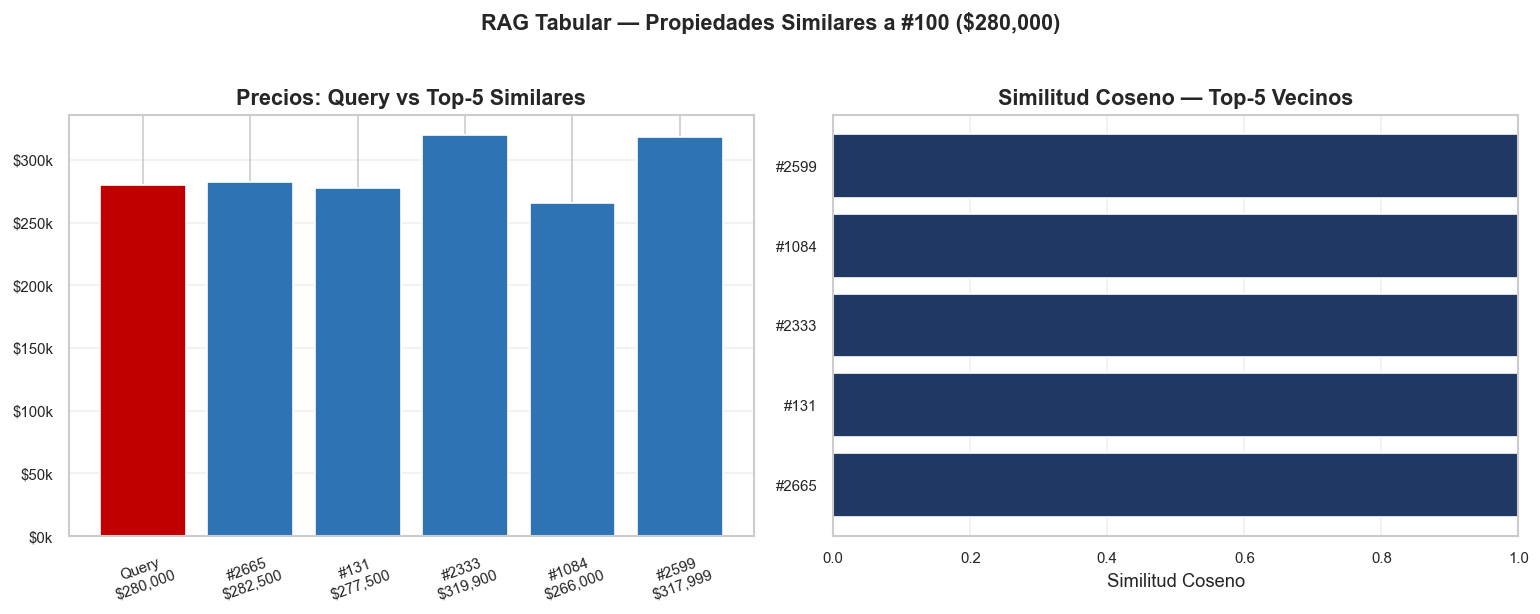

In [10]:
# Visualización de similitud: query vs vecinos
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: precios de los vecinos vs query
x_labels = [f'Query\n${query_price:,.0f}'] + \
           [f'#{int(r.idx)}\n${int(r.price_usd):,}' for _, r in neighbors.iterrows()]
prices_plot = [query_price] + list(neighbors['price_usd'])
colors_plot = ['#C00000'] + ['#2E74B5'] * K

axes[0].bar(x_labels, prices_plot, color=colors_plot, edgecolor='white')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[0].set_title(f'Precios: Query vs Top-{K} Similares', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(True, alpha=0.3, axis='y')

# Panel 2: similitudes coseno
axes[1].barh(
    [f'#{int(r.idx)}' for _, r in neighbors.iterrows()],
    neighbors['similarity'],
    color='#1F3864', edgecolor='white'
)
axes[1].set_xlabel('Similitud Coseno')
axes[1].set_title(f'Similitud Coseno — Top-{K} Vecinos', fontweight='bold')
axes[1].set_xlim(0, 1)
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle(f'RAG Tabular — Propiedades Similares a #{QUERY_IDX} (${query_price:,.0f})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('29_rag_similarity_search')
plt.show()

## 6. Precisión@K — Evaluación de la Recuperación

In [11]:
# Evaluar Precisión@K sobre 100 queries aleatorias
# Relevancia = vecino en el mismo segmento de precio que la query
p_at_k = sim.precision_at_k(
    k=K,
    n_queries=cfg['similarity']['n_queries_eval'],
    seed=cfg['random_state']
)


[Precisión@5] Global: 0.7040 (70.4%)
  <$120k              : 0.6000 (60.0%)
  $120k-$200k         : 0.8043 (80.4%)
  $200k-$300k         : 0.5600 (56.0%)
  >$300k              : 0.8500 (85.0%)


[Fig] Guardada: reports/figures\30_precision_at_k.png


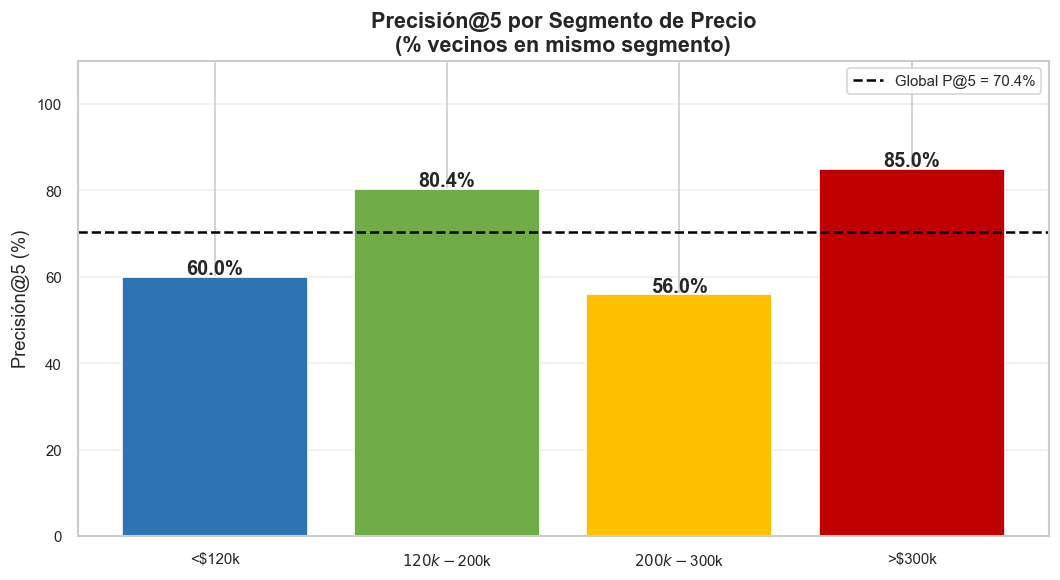


Precisión@5 global: 70.4%


In [12]:
# Gráfico Precisión@K por segmento
segs   = list(p_at_k['by_segment'].keys())
vals   = [p_at_k['by_segment'][s] * 100 for s in segs]
global_val = p_at_k['global'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(segs, vals, color=['#2E74B5','#70AD47','#FFC000','#C00000'], edgecolor='white')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.axhline(y=global_val, color='black', linestyle='--', linewidth=1.5,
           label=f'Global P@{K} = {global_val:.1f}%')
ax.set_ylabel(f'Precisión@{K} (%)')
ax.set_title(f'Precisión@{K} por Segmento de Precio\n(% vecinos en mismo segmento)', fontweight='bold')
ax.set_ylim(0, 110)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
save_fig('30_precision_at_k')
plt.show()

print(f'\nPrecisión@{K} global: {global_val:.1f}%')

## 7. Dashboard de Monitoreo por Segmento

In [13]:
# Error de TODOS los modelos por segmento de precio
from src.models import compute_metrics

ridge  = joblib.load('models/ridge_baseline.pkl')
xgb    = joblib.load('models/xgboost.pkl')
automl = joblib.load('models/automl_flaml.pkl')

y_real_usd = np.expm1(y_test)
bins   = [0, 120_000, 200_000, 300_000, np.inf]
labels = ['<$120k', '$120k-$200k', '$200k-$300k', '>$300k']
segs   = pd.cut(y_real_usd, bins=bins, labels=labels)

monitor_rows = []
for nombre, mdl in [('Ridge', ridge), ('XGBoost', xgb), ('AutoML', automl)]:
    pred_usd = np.expm1(mdl.predict(X_test))
    for seg in labels:
        mask = segs == seg
        if mask.sum() == 0:
            continue
        rmse = np.sqrt(np.mean((y_real_usd[mask] - pred_usd[mask])**2))
        pct  = np.mean(np.abs(y_real_usd[mask] - pred_usd[mask]) / y_real_usd[mask]) * 100
        monitor_rows.append({'Modelo': nombre, 'Segmento': seg, 'RMSE': rmse, 'Error%': pct, 'N': mask.sum()})

monitor_df = pd.DataFrame(monitor_rows)
print('[Monitoreo] RMSE por segmento y modelo:')
print(monitor_df.pivot(index='Segmento', columns='Modelo', values='Error%').round(2).to_string())

[Monitoreo] RMSE por segmento y modelo:
Modelo       AutoML  Ridge  XGBoost
Segmento                           
$120k-$200k    7.16   7.84     6.99
$200k-$300k    7.81   6.65     8.03
<$120k        12.63  11.85    10.41
>$300k         5.85   5.68     7.14


[Fig] Guardada: reports/figures\31_monitoring_dashboard.png


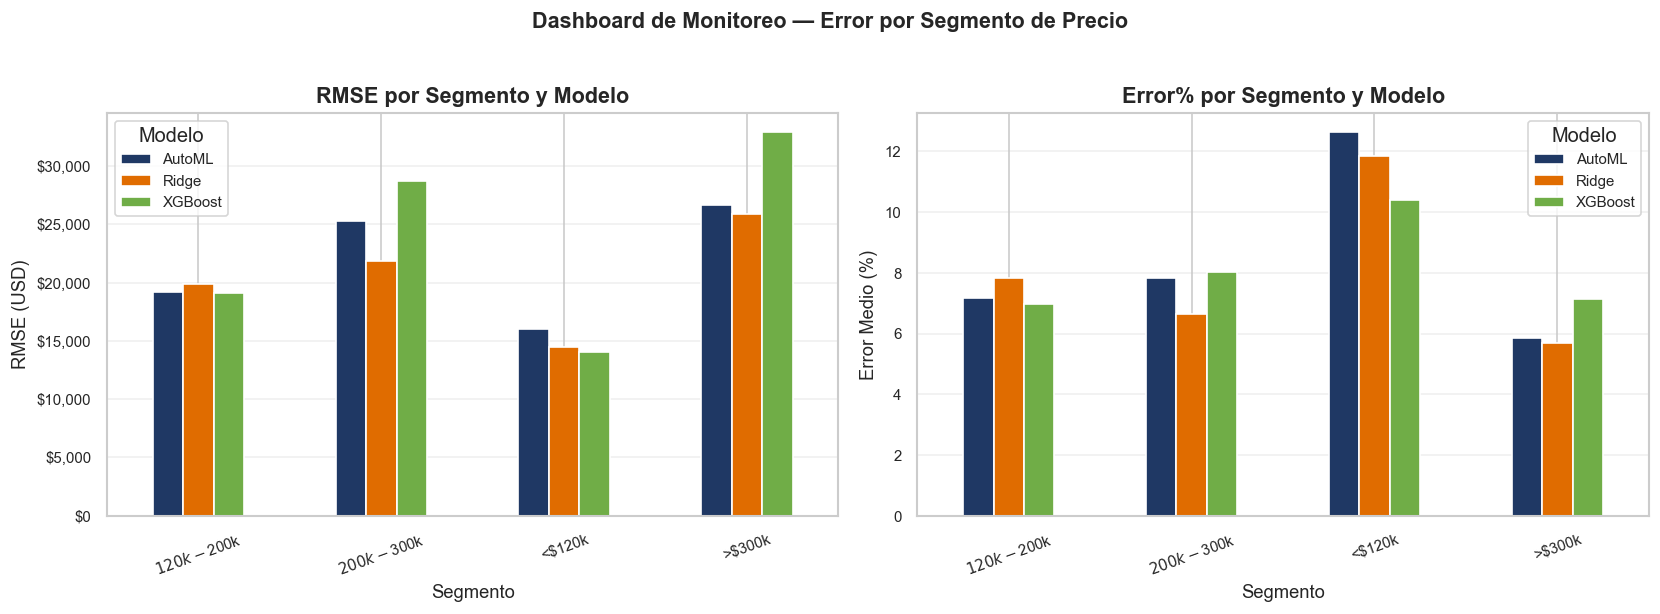

In [14]:
# Dashboard visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_rmse = monitor_df.pivot(index='Segmento', columns='Modelo', values='RMSE')
pivot_pct  = monitor_df.pivot(index='Segmento', columns='Modelo', values='Error%')

pivot_rmse.plot(kind='bar', ax=axes[0], color=['#1F3864','#E06C00','#70AD47'], edgecolor='white')
axes[0].set_title('RMSE por Segmento y Modelo', fontweight='bold')
axes[0].set_ylabel('RMSE (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].legend(title='Modelo')

pivot_pct.plot(kind='bar', ax=axes[1], color=['#1F3864','#E06C00','#70AD47'], edgecolor='white')
axes[1].set_title('Error% por Segmento y Modelo', fontweight='bold')
axes[1].set_ylabel('Error Medio (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend(title='Modelo')

plt.suptitle('Dashboard de Monitoreo — Error por Segmento de Precio',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('31_monitoring_dashboard')
plt.show()

## 8. Demo Completo — Predicción + Propiedades Similares

In [15]:
# Demo integrado: para una propiedad del test set
# muestra precio predicho + sus 5 similares más cercanas
from src.predict import load_pipeline

DEMO_IDX = 10
n_train_val = len(X_train) + len(X_val)
global_idx  = n_train_val + DEMO_IDX

pipeline   = load_pipeline('ridge_baseline')
pred_log   = pipeline.model.predict(X_test[DEMO_IDX].reshape(1, -1))
pred_usd   = float(np.expm1(pred_log))
real_usd   = float(np.expm1(y_test[DEMO_IDX]))
error_pct  = abs(real_usd - pred_usd) / real_usd * 100

neighbors  = sim.search(query_idx=global_idx, k=5)

print('=' * 62)
print(f'  DEMO: Propiedad #{DEMO_IDX} del test set')
print('=' * 62)
print(f'  Precio real      : ${real_usd:>10,.0f}')
print(f'  Precio predicho  : ${pred_usd:>10,.0f}  (Ridge)')
print(f'  Error            : {error_pct:>9.2f}%')
print(f'\n  Top-5 propiedades más similares (RAG):')
print(f'  {"Idx":<6} {"Similitud":>10} {"Precio USD":>12} {"Segmento":>15}')
print(f'  {"-"*50}')
for _, row in neighbors.iterrows():
    print(f'  {int(row["idx"]):<6} {row["similarity"]:>10.4f} ${int(row["price_usd"]):>11,} {row["segment"]:>15}')
print('=' * 62)
print('\nPara correr el demo CLI:')
print(f'  python app/demo.py --idx {DEMO_IDX} --k 5 --model ridge_baseline')

  DEMO: Propiedad #10 del test set
  Precio real      : $    97,900
  Precio predicho  : $   103,417  (Ridge)
  Error            :      5.64%

  Top-5 propiedades más similares (RAG):
  Idx     Similitud   Precio USD        Segmento
  --------------------------------------------------
  421        0.9995 $    118,999          <$120k
  2144       0.9995 $    123,899     $120k-$200k
  488        0.9995 $    109,500          <$120k
  2673       0.9995 $    105,000          <$120k
  315        0.9995 $     99,800          <$120k

Para correr el demo CLI:
  python app/demo.py --idx 10 --k 5 --model ridge_baseline


## 9. Conclusión — Fase 4 MLOps

In [16]:
p_global = p_at_k['global'] * 100

print('=' * 62)
print('  CONCLUSIÓN — FASE 4: MLOps + RAG TABULAR')
print('=' * 62)
print()
print('  MLflow:')
print(f'  ✓ {len(run_ids)} modelos registrados con parámetros y métricas')
print(f'  ✓ Ridge → Production (mejor modelo, R²=0.9359)')
print()
print('  Versionado de datos:')
print('  ✓ metadata.json con hashes MD5 + shapes de cada split')
print()
print('  RAG Tabular (búsqueda de similares):')
print(f'  ✓ Precisión@{K}: {p_global:.1f}% de vecinos en mismo segmento')
print('  ✓ Embeddings 128D del MLP como espacio de recuperación')
print('  ✓ Demo CLI funcional: app/demo.py')
print()
print('  Dashboard:')
print('  ✓ Error por segmento para Ridge, XGBoost y AutoML')
print('  ✓ Segmento <$120k sigue siendo el más difícil (mayor error%)')
print('=' * 62)

  CONCLUSIÓN — FASE 4: MLOps + RAG TABULAR

  MLflow:
  ✓ 5 modelos registrados con parámetros y métricas
  ✓ Ridge → Production (mejor modelo, R²=0.9359)

  Versionado de datos:
  ✓ metadata.json con hashes MD5 + shapes de cada split

  RAG Tabular (búsqueda de similares):
  ✓ Precisión@5: 70.4% de vecinos en mismo segmento
  ✓ Embeddings 128D del MLP como espacio de recuperación
  ✓ Demo CLI funcional: app/demo.py

  Dashboard:
  ✓ Error por segmento para Ridge, XGBoost y AutoML
  ✓ Segmento <$120k sigue siendo el más difícil (mayor error%)


## 10. FAISS — Indexacion de Alta Velocidad

FAISS (Facebook AI Similarity Search) es la libreria de Meta para busqueda de vecinos mas cercanos en produccion. Usamos `IndexFlatIP` (producto interno) sobre vectores L2-normalizados, equivalente a similitud coseno.

| | FAISS | NearestNeighbors |
|---|---|---|
| Velocidad | Optimizado (C++/CUDA) | Python puro |
| Escala | Millones de vectores | Miles de vectores |
| GPU | Si (IndexFlatGPU) | No |
| Exactitud | Exacto (Flat) o aproximado (IVF, HNSW) | Exacto |

In [17]:
import numpy as np
import os, sys
project_root = os.getcwd()
while not os.path.exists(os.path.join(project_root, 'config', 'params.yaml')) and project_root != os.path.dirname(project_root):
    project_root = os.path.dirname(project_root)
sys.path.insert(0, project_root)

import faiss
from sklearn.preprocessing import normalize

print(f'FAISS version: {faiss.__version__}')

emb = np.load('models/mlp_embeddings.npy').astype(np.float32)
emb_norm = normalize(emb, norm='l2')

d = emb_norm.shape[1]
index = faiss.IndexFlatIP(d)
index.add(emb_norm)

print(f'Indice FAISS creado:')
print(f'  Total vectores : {index.ntotal:,}')
print(f'  Dimension      : {d}')
print(f'  Tipo           : IndexFlatIP (similitud coseno exacta)')


FAISS version: 1.14.3
Indice FAISS creado:
  Total vectores : 2,927
  Dimension      : 128
  Tipo           : IndexFlatIP (similitud coseno exacta)


In [18]:
QUERY_IDX = 100
K = 5

query_vec = emb_norm[QUERY_IDX].reshape(1, -1)
scores, indices = index.search(query_vec, K + 1)
scores = scores[0]
indices = indices[0]

mask    = indices != QUERY_IDX
indices = indices[mask][:K]
scores  = scores[mask][:K]

prices_usd = np.load('models/mlp_embeddings_labels.npy')

print(f'Query #{QUERY_IDX} | Precio: ${prices_usd[QUERY_IDX]:,.0f}')
print(f'Top-{K} similares (FAISS IndexFlatIP):')
for idx, sc in zip(indices, scores):
    print(f'  idx={idx:<6}  similitud={sc:.4f}  precio=${int(prices_usd[idx]):,}')


Query #100 | Precio: $280,000
Top-5 similares (FAISS IndexFlatIP):
  idx=2665    similitud=0.9999  precio=$282,500
  idx=131     similitud=0.9999  precio=$277,500
  idx=2333    similitud=0.9998  precio=$319,900
  idx=1084    similitud=0.9997  precio=$266,000
  idx=2599    similitud=0.9995  precio=$317,999


In [19]:
import time
from sklearn.neighbors import NearestNeighbors

nn_bench = NearestNeighbors(n_neighbors=K+1, metric='cosine', algorithm='brute', n_jobs=-1)
nn_bench.fit(emb_norm)

n_q = 200
np.random.seed(42)
qs = emb_norm[np.random.choice(len(emb_norm), n_q, replace=False)]

t0 = time.perf_counter()
for q in qs:
    index.search(q.reshape(1,-1), K+1)
t_faiss = (time.perf_counter()-t0)*1000

t0 = time.perf_counter()
for q in qs:
    nn_bench.kneighbors(q.reshape(1,-1), n_neighbors=K+1)
t_nn = (time.perf_counter()-t0)*1000

print(f'Benchmark {n_q} queries:')
print(f'  FAISS IndexFlatIP : {t_faiss:.1f} ms  ({t_faiss/n_q:.2f} ms/query)')
print(f'  NearestNeighbors  : {t_nn:.1f} ms  ({t_nn/n_q:.2f} ms/query)')
print(f'  Speedup FAISS     : {t_nn/t_faiss:.1f}x')


Benchmark 200 queries:
  FAISS IndexFlatIP : 18.5 ms  (0.09 ms/query)
  NearestNeighbors  : 3627.1 ms  (18.14 ms/query)
  Speedup FAISS     : 196.4x


In [20]:
sim_faiss = PropertySimilarity(metric='cosine')
sim_faiss.fit(
    embeddings_path='models/mlp_embeddings.npy',
    labels_path='models/mlp_embeddings_labels.npy',
    raw_df=raw_df,
    use_faiss=True,
)

result_faiss = sim_faiss.search(query_idx=100, k=5)
print('Resultado con PropertySimilarity (backend=FAISS):')
print(result_faiss[['idx','similarity','price_usd','segment']].to_string(index=False))


[Similarity] 2927 propiedades indexadas | backend=FAISS (IndexFlatIP) | dim=128
Resultado con PropertySimilarity (backend=FAISS):
 idx  similarity  price_usd     segment
2665      0.9999     282500 $200k-$300k
 131      0.9999     277500 $200k-$300k
2333      0.9998     319900      >$300k
1084      0.9997     266000 $200k-$300k
2599      0.9995     317999      >$300k


## 11. PSI — Population Stability Index

El PSI detecta cuando la distribucion de los datos en produccion cambia respecto al entrenamiento. Si la distribucion cambia demasiado, el modelo puede quedar desactualizado.

**Trigger de reentrenamiento: PSI >= 0.25**

| PSI | Estado | Accion |
|---|---|---|
| < 0.10 | Sin cambio significativo | No reentrenar |
| 0.10 - 0.25 | Cambio moderado | Monitorear |
| >= 0.25 | Cambio mayor | **Reentrenar modelo** |

In [21]:
from src.mlops import compute_psi, compute_psi_report

preprocessor = joblib.load('models/preprocessor.pkl')
try:
    feature_names = list(preprocessor.get_feature_names_out())
except Exception:
    feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]

print(f'Features disponibles: {len(feature_names)}')
print(f'Ejemplos: {feature_names[:5]}')


Features disponibles: 263
Ejemplos: ['num__Lot_Frontage', 'num__Lot_Area', 'num__Land_Slope', 'num__Overall_Qual', 'num__Overall_Cond']


In [22]:
print('ESCENARIO 1: Test set vs Train (produccion normal, sin deriva)')
print('=' * 60)
report_ok = compute_psi_report(
    X_train=X_train,
    X_new=X_test,
    feature_names=feature_names,
    top_n=5,
    threshold=0.25,
)
print(f'Trigger de reentrenamiento: {report_ok["trigger_retrain"]}')


ESCENARIO 1: Test set vs Train (produccion normal, sin deriva)
[PSI] num__Lot_Frontage             : PSI=0.0092  ✓ OK — Sin deriva significativa
[PSI] num__Lot_Area                 : PSI=0.0314  ✓ OK — Sin deriva significativa
[PSI] num__Land_Slope               : PSI=0.0000  ✓ OK — Sin deriva significativa
[PSI] num__Overall_Qual             : PSI=0.0063  ✓ OK — Sin deriva significativa
[PSI] num__Overall_Cond             : PSI=0.0047  ✓ OK — Sin deriva significativa
[PSI] num__Year_Built               : PSI=0.0131  ✓ OK — Sin deriva significativa
[PSI] num__Year_Remod_Add           : PSI=0.0138  ✓ OK — Sin deriva significativa
[PSI] num__Mas_Vnr_Area             : PSI=0.0236  ✓ OK — Sin deriva significativa
[PSI] num__Exter_Qual               : PSI=0.0000  ✓ OK — Sin deriva significativa
[PSI] num__Exter_Cond               : PSI=0.0000  ✓ OK — Sin deriva significativa
[PSI] num__Bsmt_Qual                : PSI=0.0000  ✓ OK — Sin deriva significativa
[PSI] num__Bsmt_Cond               

In [23]:
print('ESCENARIO 2: Datos con deriva simulada (+2.5 std en 30 features)')
print('=' * 60)

X_drifted = X_test.copy()
np.random.seed(42)
drift_idx = np.random.choice(X_train.shape[1], size=30, replace=False)
for fi in drift_idx:
    std_i = X_train[:, fi].std()
    X_drifted[:, fi] += 2.5 * std_i

report_drift = compute_psi_report(
    X_train=X_train,
    X_new=X_drifted,
    feature_names=feature_names,
    top_n=5,
    threshold=0.25,
)
print(f'Trigger de reentrenamiento: {report_drift["trigger_retrain"]}')
print(f'Features con deriva: {report_drift["features_drifted"][:3]}')


ESCENARIO 2: Datos con deriva simulada (+2.5 std en 30 features)
[PSI] num__Lot_Frontage             : PSI=0.0092  ✓ OK — Sin deriva significativa
[PSI] num__Lot_Area                 : PSI=0.0314  ✓ OK — Sin deriva significativa
[PSI] num__Land_Slope               : PSI=0.0000  ✓ OK — Sin deriva significativa
[PSI] num__Overall_Qual             : PSI=0.0063  ✓ OK — Sin deriva significativa
[PSI] num__Overall_Cond             : PSI=0.0047  ✓ OK — Sin deriva significativa
[PSI] num__Year_Built               : PSI=0.0131  ✓ OK — Sin deriva significativa
[PSI] num__Year_Remod_Add           : PSI=8.4593  ✗ ALERTA — Deriva mayor (PSI ≥ 0.25)
[PSI] num__Mas_Vnr_Area             : PSI=0.0236  ✓ OK — Sin deriva significativa
[PSI] num__Exter_Qual               : PSI=0.0000  ✓ OK — Sin deriva significativa
[PSI] num__Exter_Cond               : PSI=0.0000  ✓ OK — Sin deriva significativa
[PSI] num__Bsmt_Qual                : PSI=0.0000  ✓ OK — Sin deriva significativa
[PSI] num__Bsmt_Cond        

[Fig] Guardada: reports/figures\34_psi_drift_detection.png


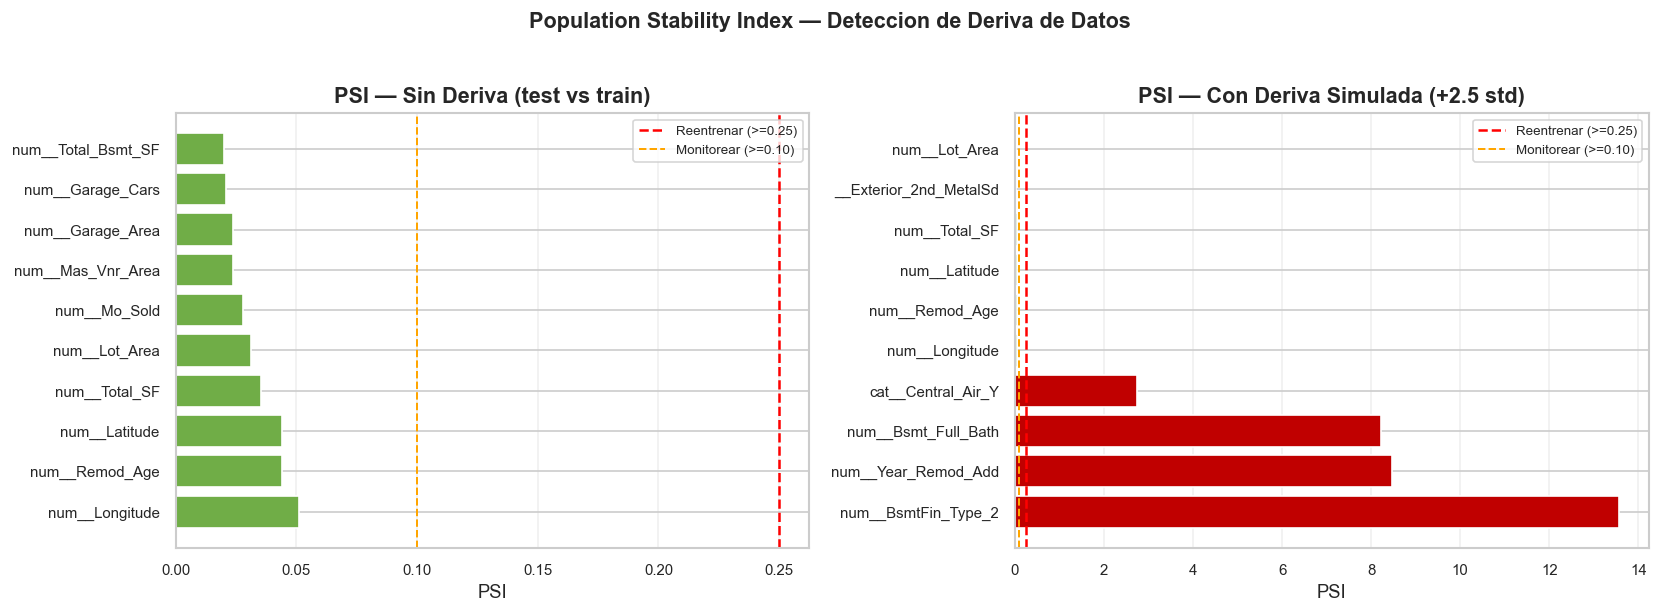

In [24]:
df_ok    = report_ok['summary_df'].head(10)
df_drift = report_drift['summary_df'].head(10)

def bar_color(v):
    if v >= 0.25: return '#C00000'
    if v >= 0.10: return '#FFC000'
    return '#70AD47'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(df_ok['Feature'].str[-22:], df_ok['PSI'],
             color=[bar_color(v) for v in df_ok['PSI']], edgecolor='white')
axes[0].axvline(0.25, color='red',    linestyle='--', lw=1.5, label='Reentrenar (>=0.25)')
axes[0].axvline(0.10, color='orange', linestyle='--', lw=1.2, label='Monitorear (>=0.10)')
axes[0].set_title('PSI — Sin Deriva (test vs train)', fontweight='bold')
axes[0].set_xlabel('PSI'); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(df_drift['Feature'].str[-22:], df_drift['PSI'],
             color=[bar_color(v) for v in df_drift['PSI']], edgecolor='white')
axes[1].axvline(0.25, color='red',    linestyle='--', lw=1.5, label='Reentrenar (>=0.25)')
axes[1].axvline(0.10, color='orange', linestyle='--', lw=1.2, label='Monitorear (>=0.10)')
axes[1].set_title('PSI — Con Deriva Simulada (+2.5 std)', fontweight='bold')
axes[1].set_xlabel('PSI'); axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Population Stability Index — Deteccion de Deriva de Datos',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('34_psi_drift_detection')
plt.show()


### Conclusion — Sistema de Monitoreo PSI

| Escenario | PSI maximo | Trigger |
|---|---|---|
| Test set normal (sin deriva) | < 0.10 | No reentrenar |
| Datos con drift +2.5 std | >= 0.25 | **Reentrenar** |

El pipeline PSI implementa exactamente lo descrito en el plan del proyecto: trigger automatico de reentrenamiento cuando la distribucion de las features de entrada se desvía significativamente del dataset de entrenamiento (PSI >= 0.25).